In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Actual ranking
df = pd.read_csv('resultsaftergreece.csv')
df.columns = ['rank', 'ewc', 'enc', 'country', 'player', 'china', 'france',
       'usa', 'brazil', 'greece', '? #6', '? #7', '? #8', '? #9',
       '? #10', 'total_points']

df = df[['rank', 'country', 'player','total_points']]
df

,rank,country,player,total_points
0,1,France,Binkss.,2410
1,2,Australia,AR_Mudda,2364
2,3,Canada,CarlJr.,2032
3,4,Germany,GranaDy.,1620
4,5,Germany,MASSA_,1570
...,...,...,...,...
100,101,Norway,Intax,4
101,102,France,REZAAISBACK,2
102,103,Poland,Demotivator13,2
103,104,World,propanoia,2


In [4]:
enc = df.drop_duplicates(subset='country').copy()
enc['qualified'] = 0
enc.loc[enc.head(16).index,'qualified'] = 1
enc = enc.reset_index(drop=True)
enc['country_rank'] = enc.index + 1
enc

,rank,country,player,total_points,qualified,country_rank
0,1,France,Binkss.,2410,1,1
1,2,Australia,AR_Mudda,2364,1,2
2,3,Canada,CarlJr.,2032,1,3
3,4,Germany,GranaDy.,1620,1,4
4,9,United Kingdom,Epos.,852,1,5
5,12,Poland,mime-,742,1,6
6,14,Belgium,Scrapie98,682,1,7
7,16,Czechia,eLconn21,636,1,8
8,22,Sweden,Molle_.,316,1,9
9,24,Hungary,pusztitopako,290,1,10


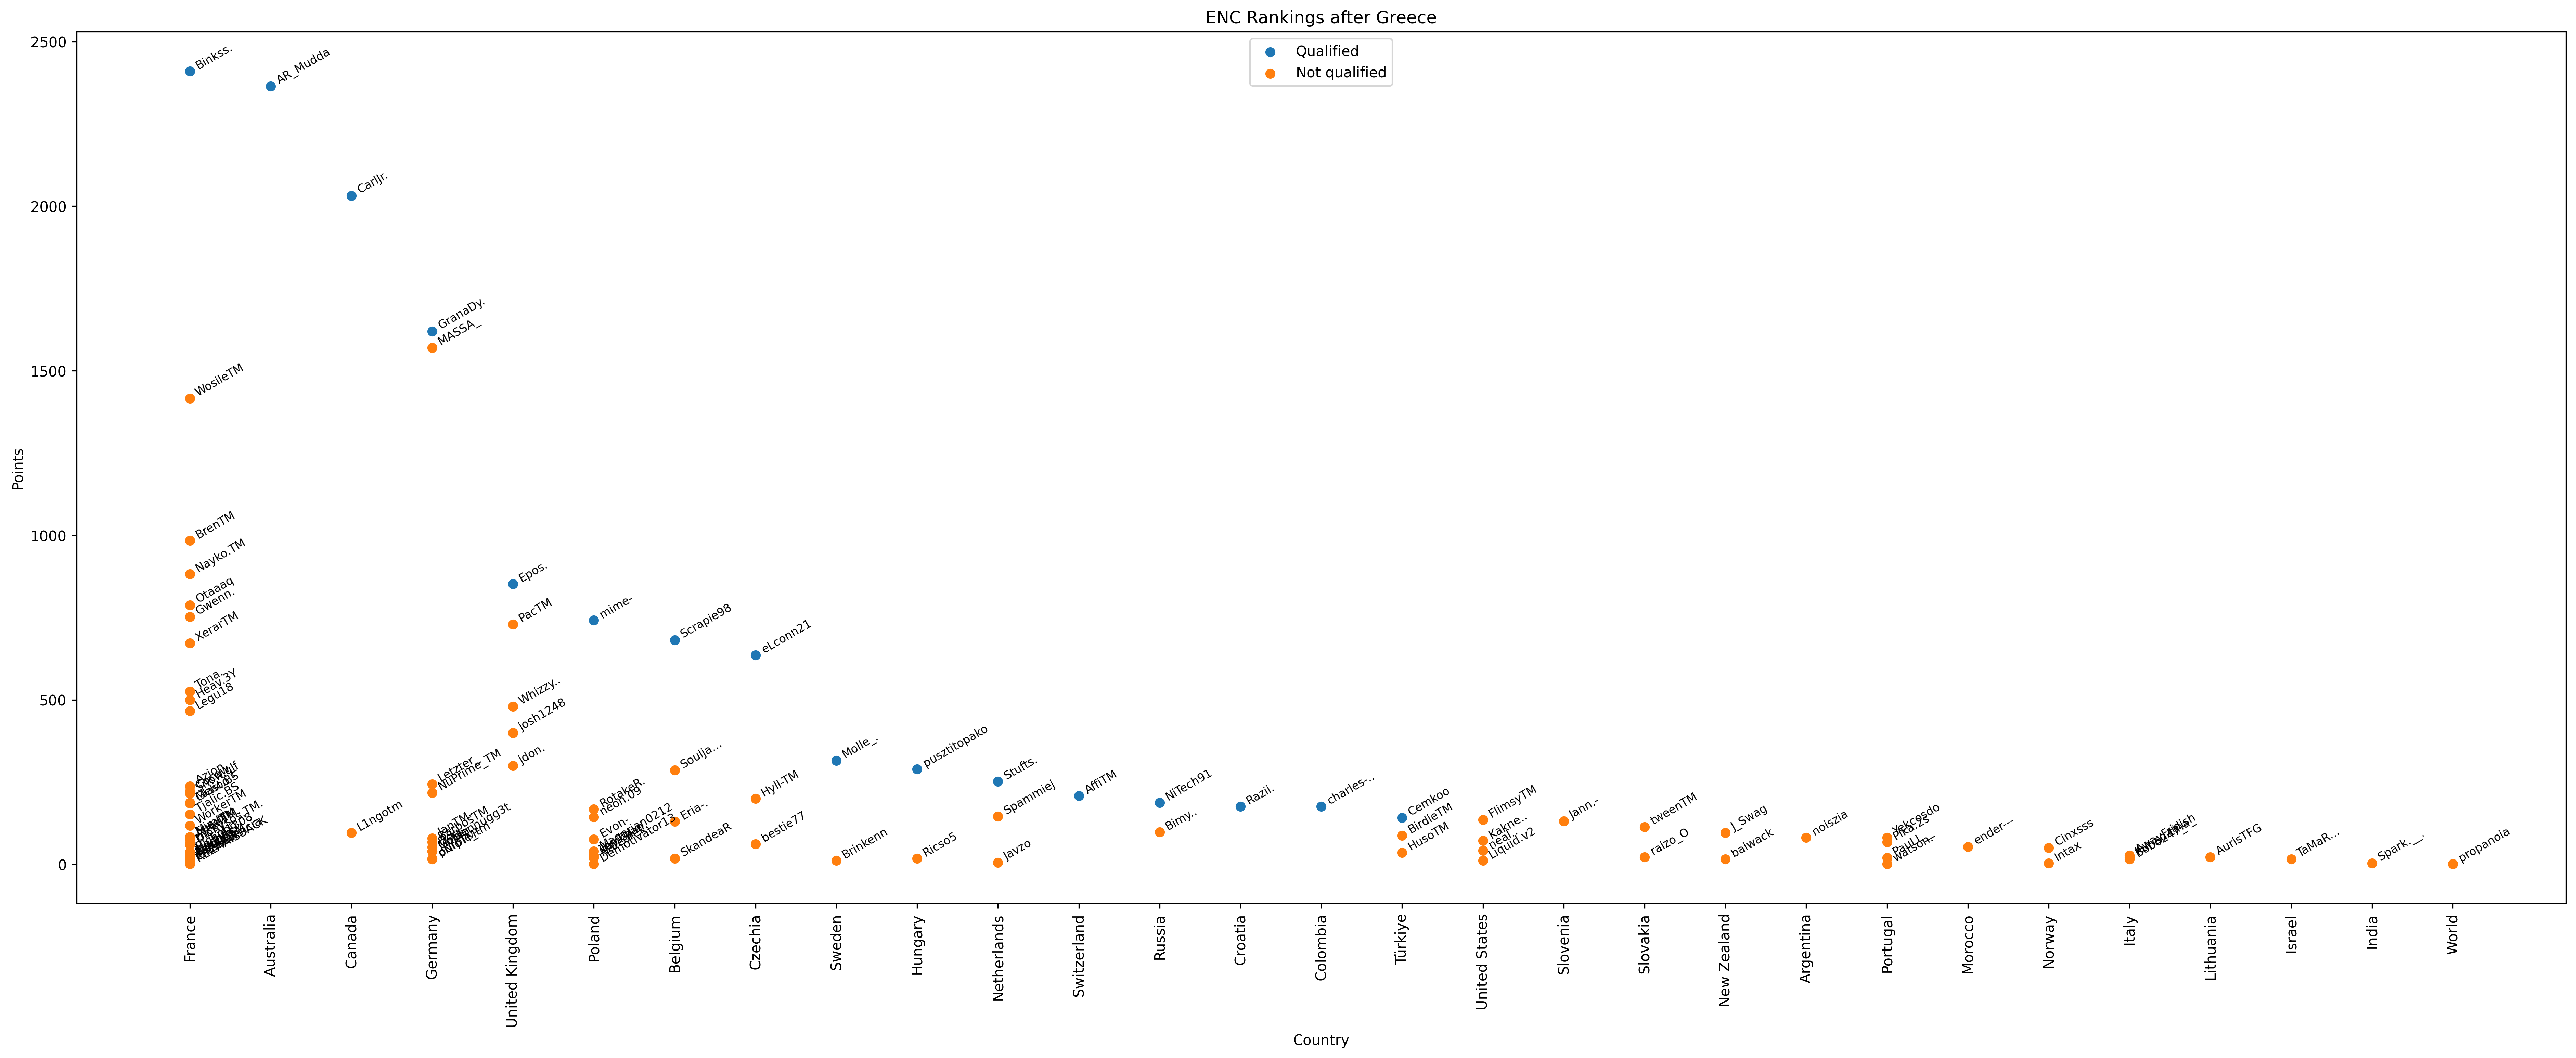

In [47]:
fig, ax = plt.subplots(figsize=(25,10),dpi=300)

to_plot = pd.merge(df,enc[['country','country_rank']],left_on='country',right_on='country',how='left')
to_plot = pd.merge(to_plot,enc[['player','qualified']],on='player',how='left').fillna(0)

ax.scatter(to_plot[to_plot.qualified == 1].country_rank,to_plot[to_plot.qualified == 1].total_points)
ax.scatter(to_plot[to_plot.qualified == 0].country_rank,to_plot[to_plot.qualified == 0].total_points)

ax.set_xticks(range(1,to_plot.country_rank.max()+1))
ax.set_xticklabels(enc.country.tolist(),rotation=90)

for idx in to_plot.index:
    ax.text(to_plot.country_rank[idx]+0.05,to_plot.total_points[idx],to_plot.player[idx],va='bottom',size=8,rotation=30)

fig.tight_layout()
ax.legend(['Qualified','Not qualified'],loc='upper center')
ax.set_title('ENC Rankings after Greece')
ax.set_xlabel('Country')
ax.set_ylabel('Points')
fig.savefig('20260314_enc_rankings.png', format='png', pad_inches=0, dpi=300)